In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (RandomForestRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)

from sklearn.metrics import (r2_score,
    mean_absolute_error,
    mean_squared_error
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [2]:
Concrete = pd.read_excel("Concrete_Data.xls")
Concrete.head()

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [3]:
Concrete.columns = [
    'Cement',
    'Blast_Furnace_Slag',
    'Fly_Ash',
    'Water',
    'Superplasticizer',
    'Coarse_Aggregate',
    'Fine_Aggregate',
    'Age',
    'Compressive_Strength'
]

Concrete.head()

,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Compressive_Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [4]:
Concrete.shape

(1030, 9)

In [5]:
Concrete.columns

Index(['Cement', 'Blast_Furnace_Slag', 'Fly_Ash', 'Water', 'Superplasticizer',
       'Coarse_Aggregate', 'Fine_Aggregate', 'Age', 'Compressive_Strength'],
      dtype='object')

In [6]:
Concrete.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Cement                1030 non-null   float64
 1   Blast_Furnace_Slag    1030 non-null   float64
 2   Fly_Ash               1030 non-null   float64
 3   Water                 1030 non-null   float64
 4   Superplasticizer      1030 non-null   float64
 5   Coarse_Aggregate      1030 non-null   float64
 6   Fine_Aggregate        1030 non-null   float64
 7   Age                   1030 non-null   int64  
 8   Compressive_Strength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.5 KB


In [7]:
Concrete.isnull().sum()

Cement                  0
Blast_Furnace_Slag      0
Fly_Ash                 0
Water                   0
Superplasticizer        0
Coarse_Aggregate        0
Fine_Aggregate          0
Age                     0
Compressive_Strength    0
dtype: int64

In [8]:
Concrete.describe()

,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Compressive_Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


In [9]:
Concrete.duplicated().sum()

np.int64(25)

In [10]:
# Check duplicate rows
duplicates = Concrete[Concrete.duplicated()]
duplicates.shape[0]

# View duplicates
duplicates.head()

,Cement,Blast_Furnace_Slag,Fly_Ash,Water,Superplasticizer,Coarse_Aggregate,Fine_Aggregate,Age,Compressive_Strength
77,425.0,106.3,0.0,153.5,16.5,852.1,887.1,3,33.398217
80,425.0,106.3,0.0,153.5,16.5,852.1,887.1,3,33.398217
86,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.301171
88,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.301171
91,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.301171


In [11]:
# Remove duplicates
Concrete = Concrete.drop_duplicates()

# Verify removal
print("New Shape:", Concrete.shape)
print("Remaining Duplicates:", Concrete.duplicated().sum())

New Shape: (1005, 9)
Remaining Duplicates: 0


In [12]:
Concrete.nunique()

Cement                  280
Blast_Furnace_Slag      187
Fly_Ash                 163
Water                   205
Superplasticizer        155
Coarse_Aggregate        284
Fine_Aggregate          304
Age                      14
Compressive_Strength    938
dtype: int64

In [13]:
Concrete['Age'].value_counts().sort_index()

Age
1        2
3      129
7      122
14      62
28     419
56      86
90      54
91      17
100     52
120      3
180     26
270     13
360      6
365     14
Name: count, dtype: int64

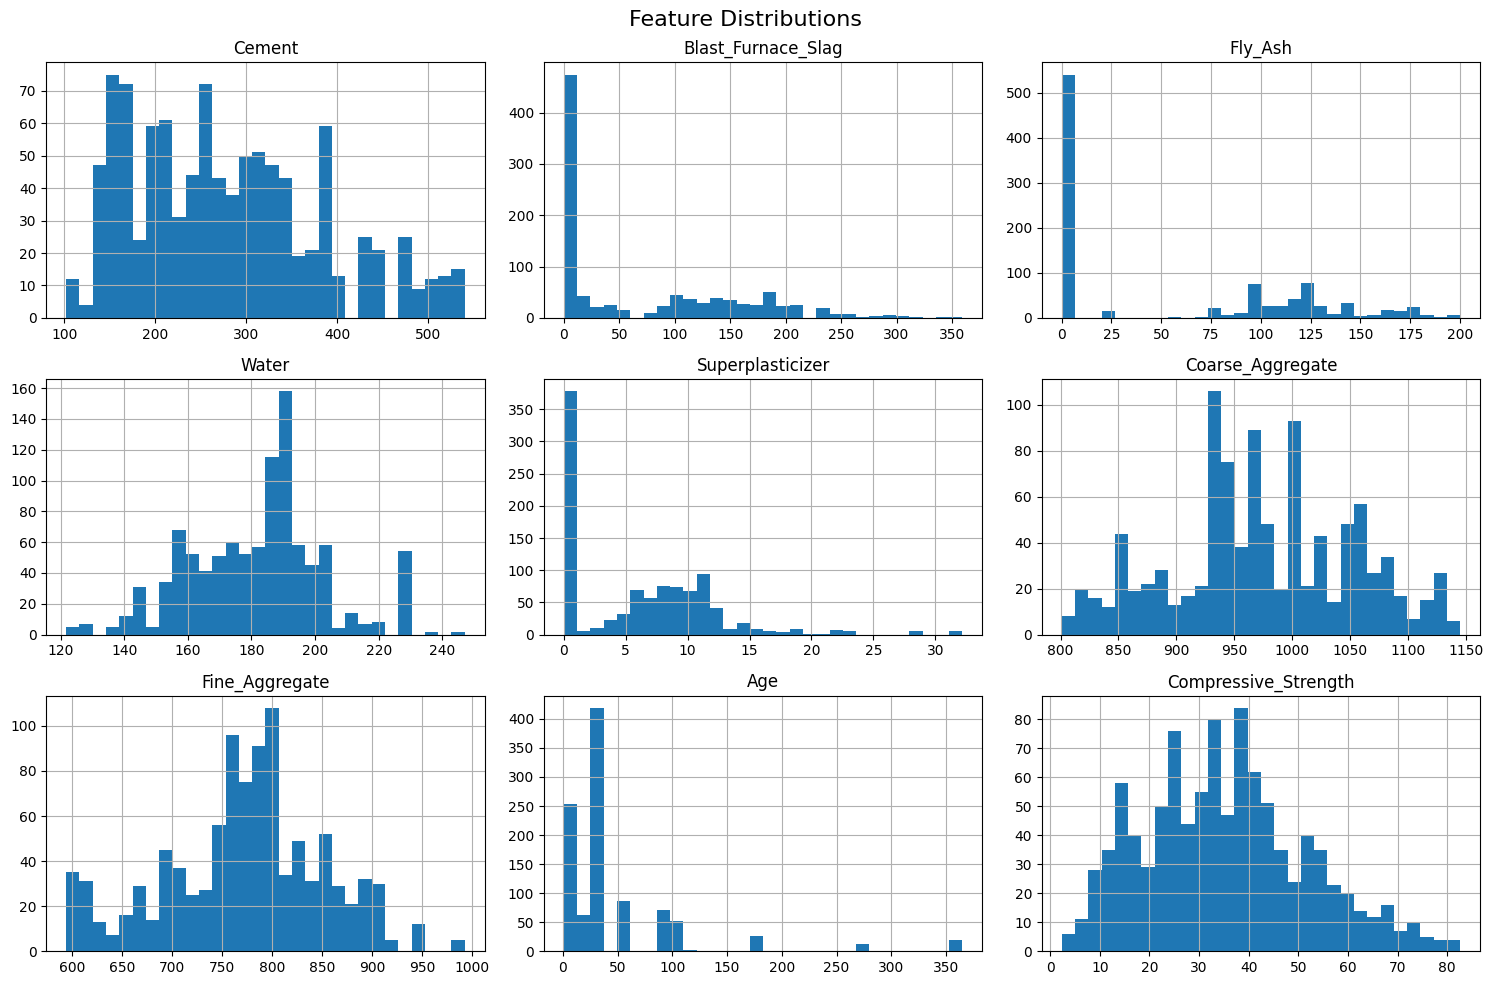

In [14]:
# Histograms for all features
Concrete.hist(figsize=(15, 10), bins=30)
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

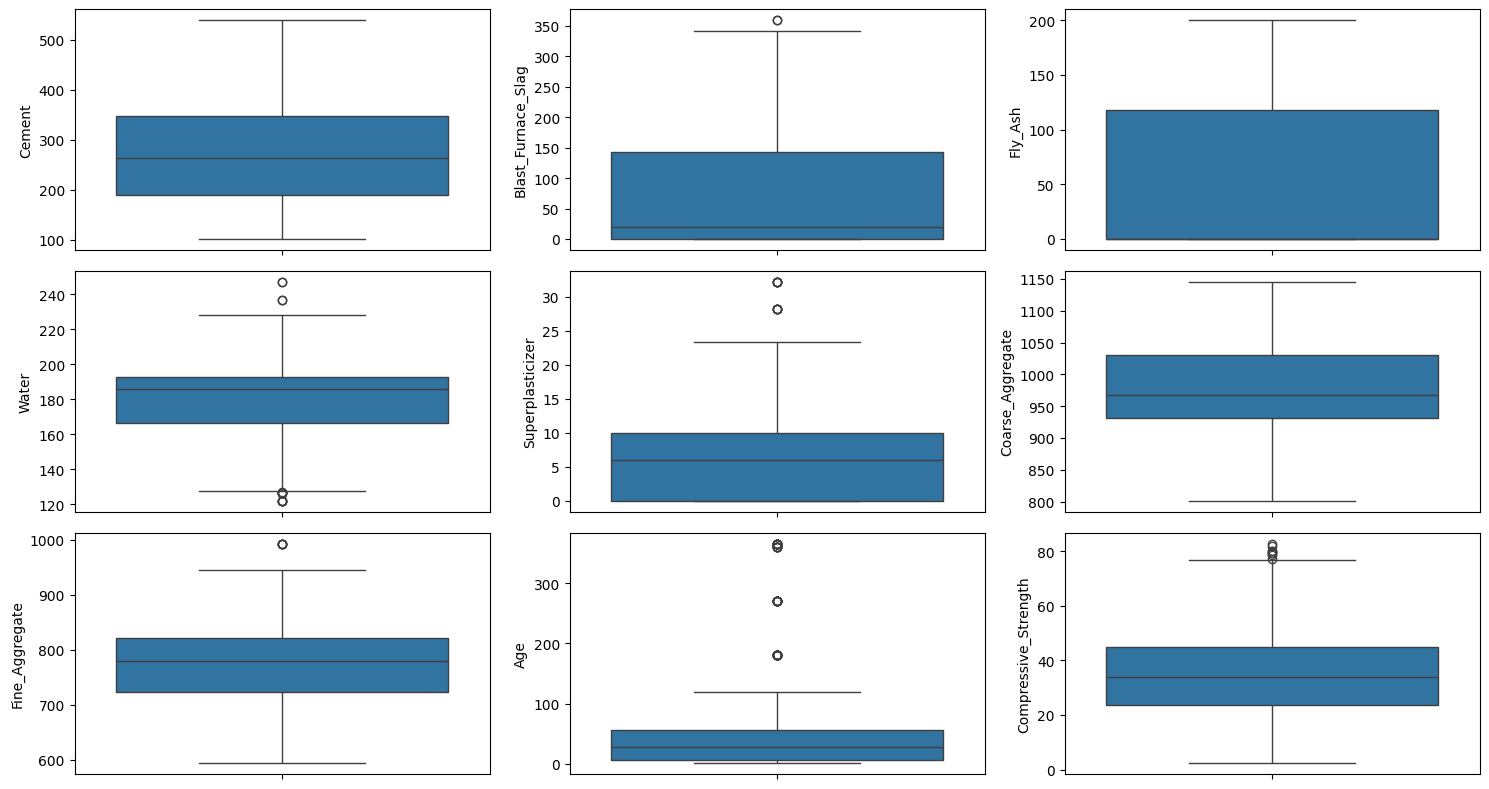

In [15]:
plt.figure(figsize=(15,8))

for i, col in enumerate(Concrete.columns, 1):
    plt.subplot(3,3,i)
    sns.boxplot(y=Concrete[col])

plt.tight_layout()
plt.show()

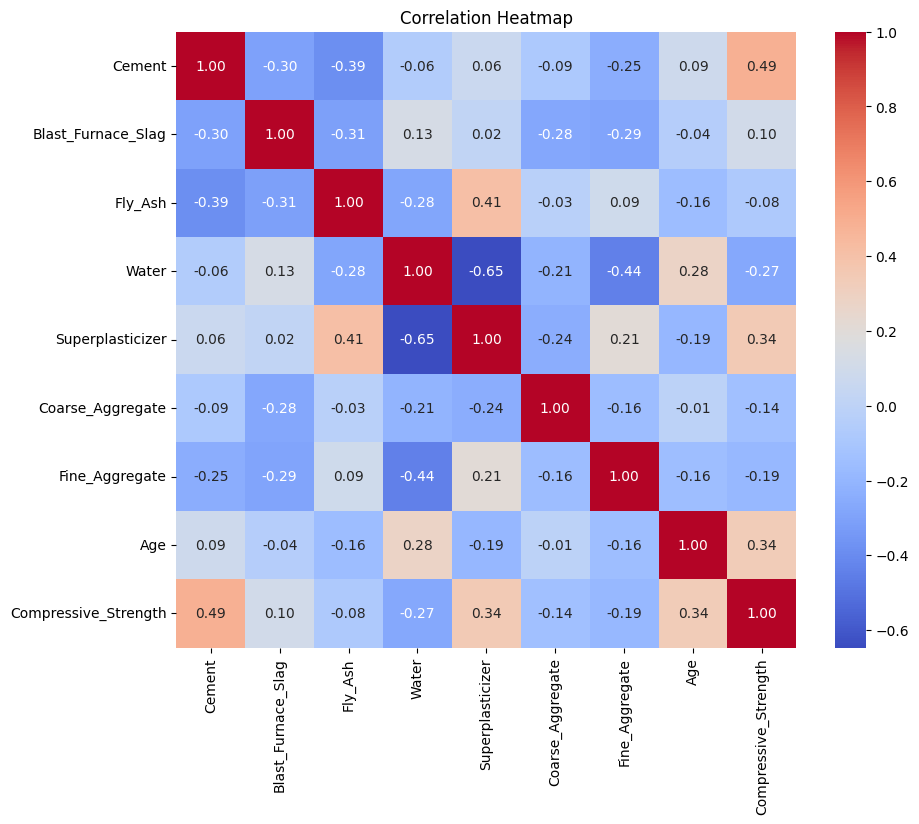

In [16]:
plt.figure(figsize=(10,8))

sns.heatmap(
    Concrete.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

In [17]:
corr_strength = (
    Concrete.corr()['Compressive_Strength']
    .sort_values(ascending=False)
)

print(corr_strength)

Compressive_Strength    1.000000
Cement                  0.488283
Superplasticizer        0.344225
Age                     0.337371
Blast_Furnace_Slag      0.103370
Fly_Ash                -0.080648
Coarse_Aggregate       -0.144710
Fine_Aggregate         -0.186457
Water                  -0.269606
Name: Compressive_Strength, dtype: float64


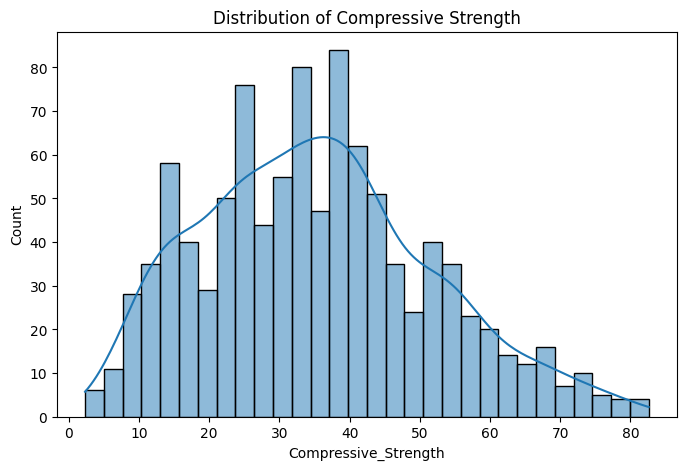

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(Concrete['Compressive_Strength'],bins=30,kde=True)

plt.title("Distribution of Compressive Strength")
plt.show()

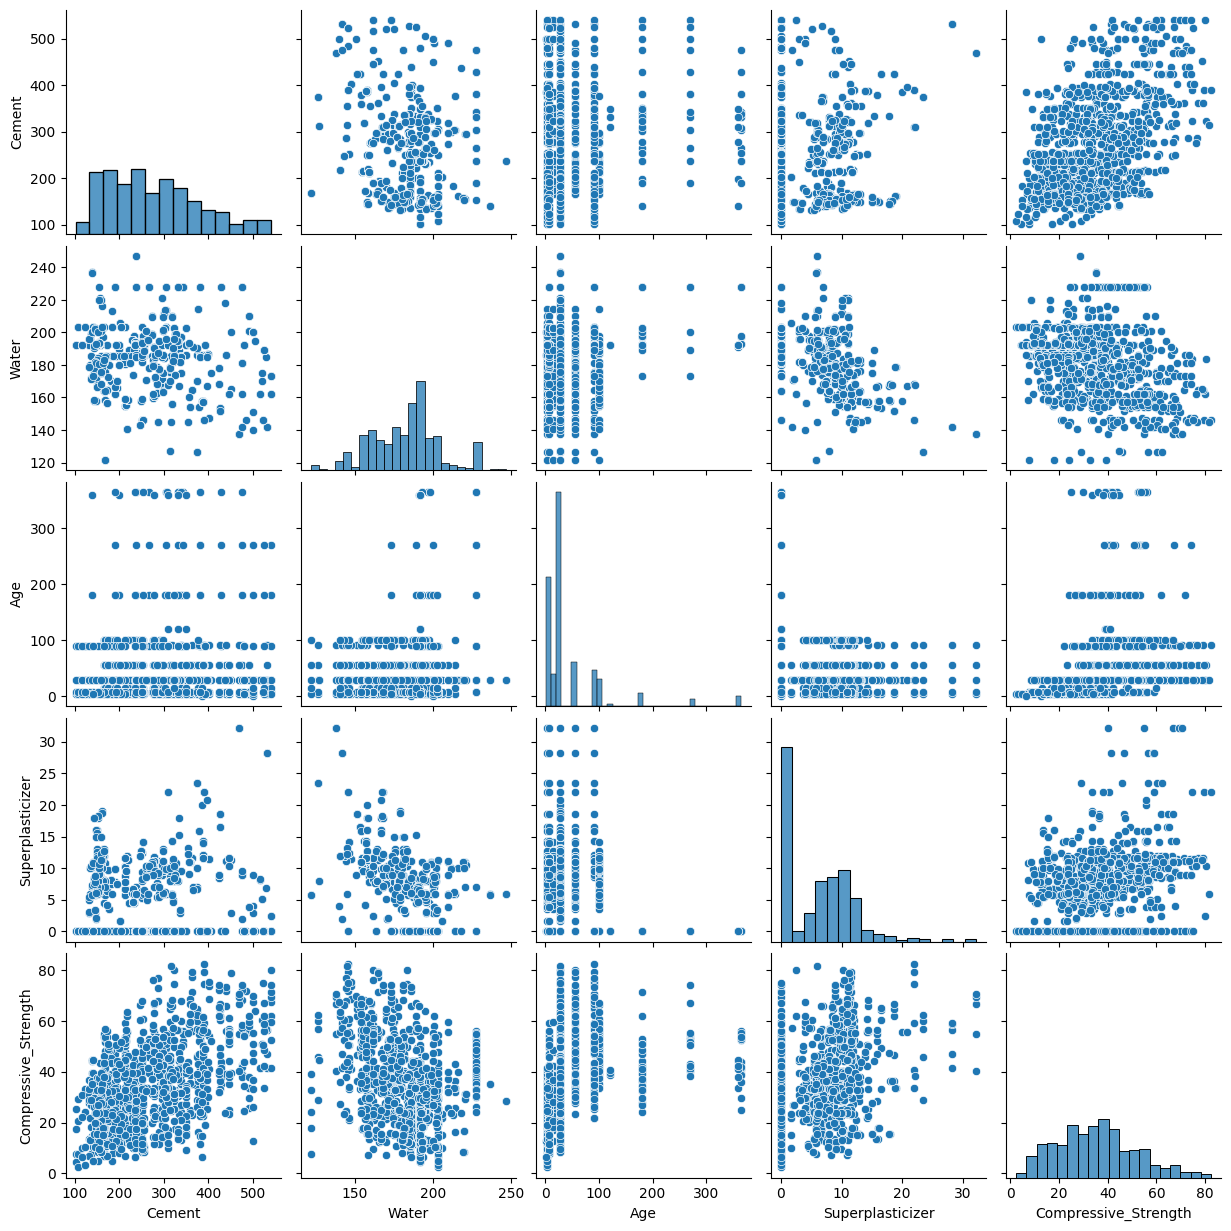

In [19]:
sns.pairplot(
    Concrete[['Cement',
              'Water',
              'Age',
              'Superplasticizer',
              'Compressive_Strength']]
)

plt.show()

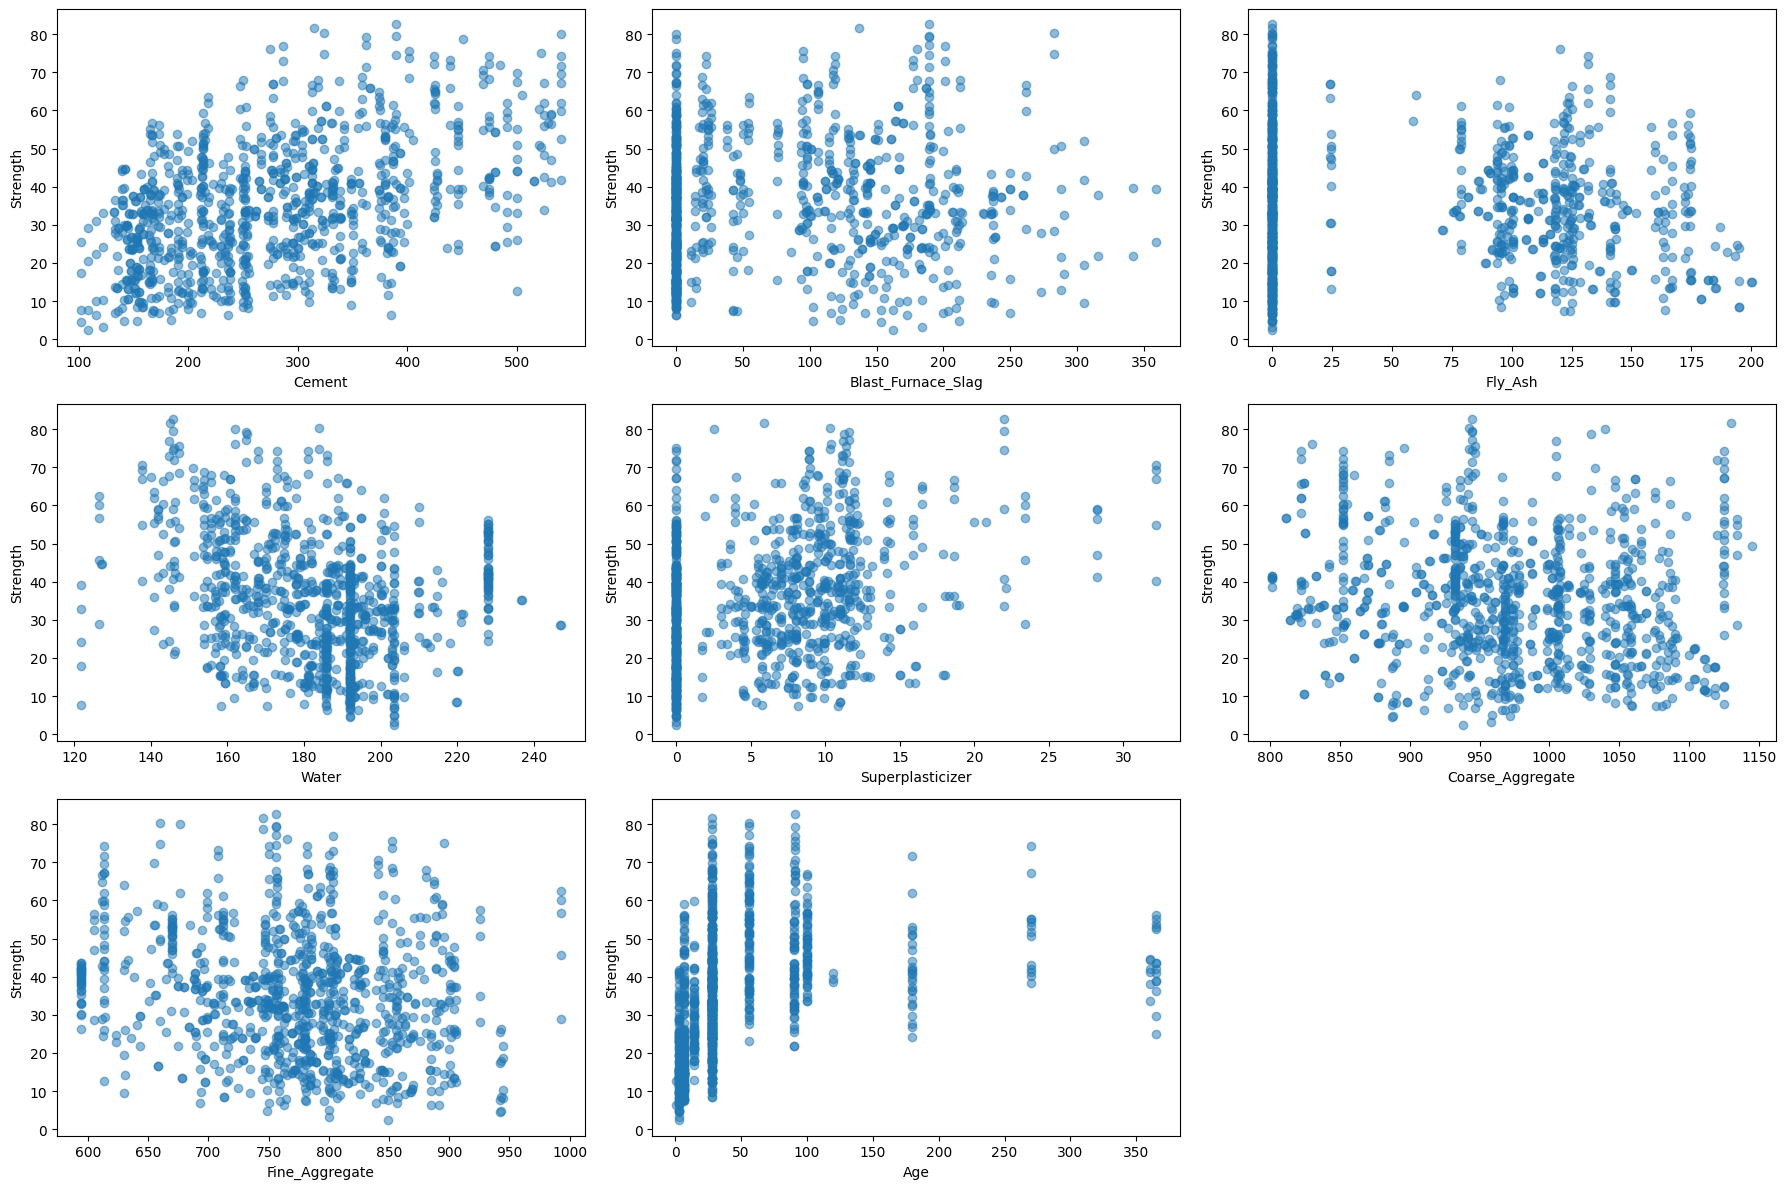

In [20]:
features = [
    'Cement',
    'Blast_Furnace_Slag',
    'Fly_Ash',
    'Water',
    'Superplasticizer',
    'Coarse_Aggregate',
    'Fine_Aggregate',
    'Age'
]

plt.figure(figsize=(18,12))

for i, feature in enumerate(features, 1):
    plt.subplot(3,3,i)
    plt.scatter(
        Concrete[feature],
        Concrete['Compressive_Strength'],
        alpha=0.5
    )
    plt.xlabel(feature)
    plt.ylabel('Strength')

plt.tight_layout()
plt.show()

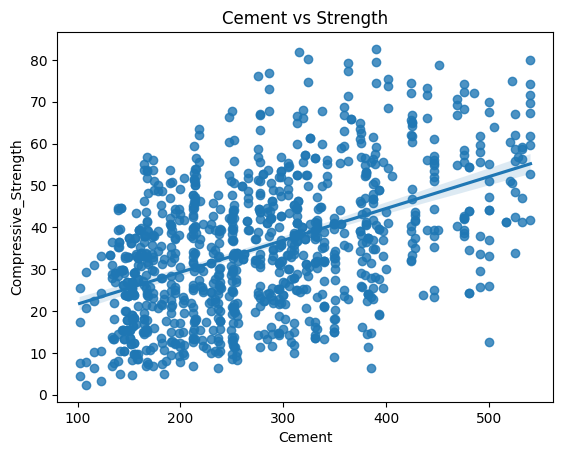

In [21]:
sns.regplot(x='Cement',
    y='Compressive_Strength',
    data=Concrete
)

plt.title("Cement vs Strength")
plt.show()

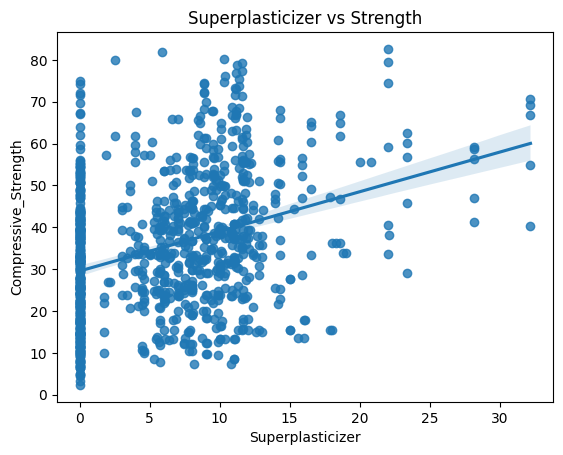

In [22]:
sns.regplot(x='Superplasticizer',
    y='Compressive_Strength',
    data=Concrete
)

plt.title("Superplasticizer vs Strength")
plt.show()

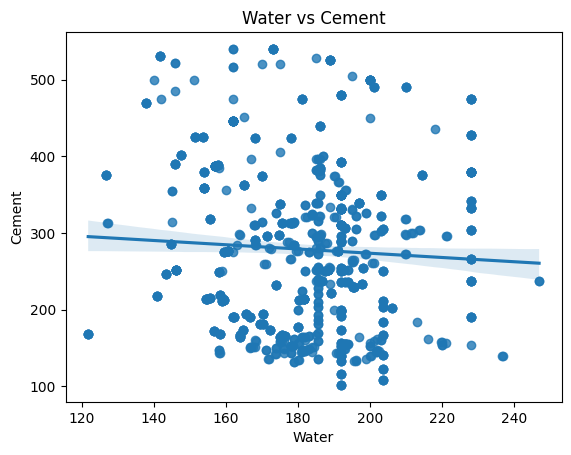

In [23]:
sns.regplot(x='Water',
    y='Cement',
    data=Concrete
)

plt.title("Water vs Cement")
plt.show()

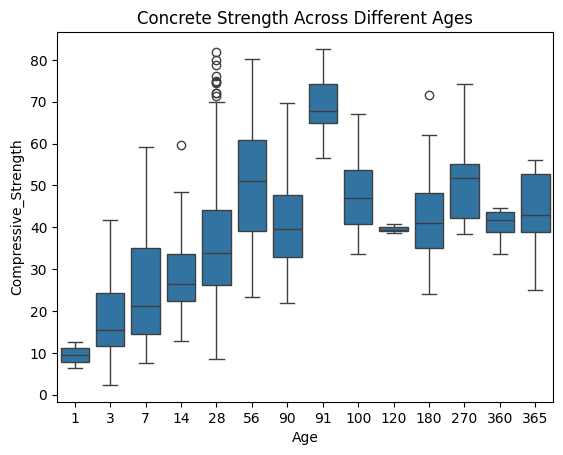

In [24]:
sns.boxplot(
    x='Age',
    y='Compressive_Strength',
    data=Concrete
)

#plt.xticks(rotation=45)
plt.title("Concrete Strength Across Different Ages")
plt.show()

In [25]:
X = Concrete.drop('Compressive_Strength', axis=1)

y = Concrete['Compressive_Strength']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.8,
    random_state=42)

In [27]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestRegressor(
            random_state=42
        ))
    ]),

    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GradientBoostingRegressor(
            random_state=42
        ))
    ]),

    "Hist Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("model", HistGradientBoostingRegressor(
            random_state=42
        ))
    ])
}

In [29]:
results = []

for name, pipeline in models.items():

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Metrics
    r2 = r2_score(y_test, y_pred)

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    results.append([
        name,
        r2,
        mae,
        rmse
    ])

    print(f"\n{name}")
    print("-"*40)
    print(f"R² Score : {r2:.4f}")
    print(f"MAE      : {mae:.4f}")
    print(f"RMSE     : {rmse:.4f}")


Linear Regression
----------------------------------------
R² Score : 0.5801
MAE      : 8.8960
RMSE     : 11.1922

Random Forest
----------------------------------------
R² Score : 0.9119
MAE      : 3.4264
RMSE     : 5.1263

Gradient Boosting
----------------------------------------
R² Score : 0.8979
MAE      : 4.0987
RMSE     : 5.5193

Hist Gradient Boosting
----------------------------------------
R² Score : 0.9304
MAE      : 3.0504
RMSE     : 4.5577


In [30]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "R2 Score",
        "MAE",
        "RMSE"
    ]
)

results_df.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,R2 Score,MAE,RMSE
3,Hist Gradient Boosting,0.930370,3.050368,4.557703
1,Random Forest,0.911912,3.426361,5.126311
2,Gradient Boosting,0.897887,4.098668,5.519350
0,Linear Regression,0.580109,8.896028,11.192200


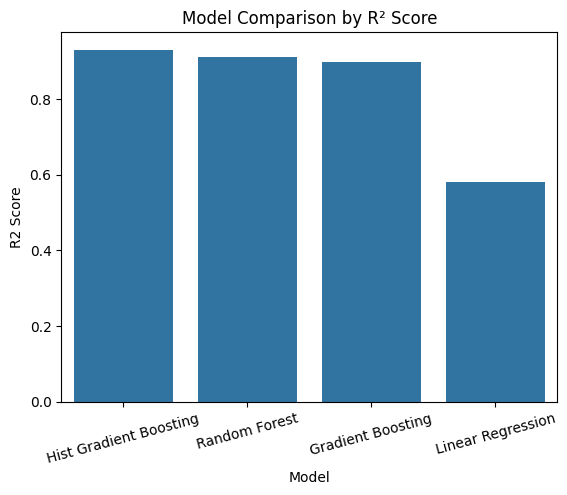

In [31]:
sns.barplot(
    data=results_df.sort_values(
        by='R2 Score',
        ascending=False
    ),
    x='Model',
    y='R2 Score'
)

plt.title("Model Comparison by R² Score")
plt.xticks(rotation=15)

plt.show()

In [32]:
from sklearn.model_selection import RandomizedSearchCV
rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(random_state=42))
])

rf_params = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 10, 20, 30, 40],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best Parameters:")
print(rf_search.best_params_)

print("\nBest CV Score:")
print(rf_search.best_score_)

Best Parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': 40}

Best CV Score:
0.8878025637823873


In [33]:
hgb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", HistGradientBoostingRegressor(
        random_state=42
    ))
])

hgb_params = {
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 5, 7, 10],
    "model__max_iter": [100, 200, 300],
    "model__min_samples_leaf": [10, 20, 30]
}

hgb_search = RandomizedSearchCV(
    hgb_pipeline,
    hgb_params,
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

hgb_search.fit(X_train, y_train)

print("Best Parameters:")
print(hgb_search.best_params_)

print("\nBest CV Score:")
print(hgb_search.best_score_)

Best Parameters:
{'model__min_samples_leaf': 20, 'model__max_iter': 300, 'model__max_depth': 10, 'model__learning_rate': 0.1}

Best CV Score:
0.9181686298224816


In [34]:
rf_best = rf_search.best_estimator_

rf_pred = rf_best.predict(X_test)

print("R²:", r2_score(y_test, rf_pred))
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))

R²: 0.9119752021406288
MAE: 3.4702116571664714
RMSE: 5.124478109789523


In [35]:
hgb_best = hgb_search.best_estimator_

hgb_pred = hgb_best.predict(X_test)

print("R²:", r2_score(y_test, hgb_pred))
print("MAE:", mean_absolute_error(y_test, hgb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, hgb_pred)))

R²: 0.9390427278953636
MAE: 2.7574964635106136
RMSE: 4.2644191596017444


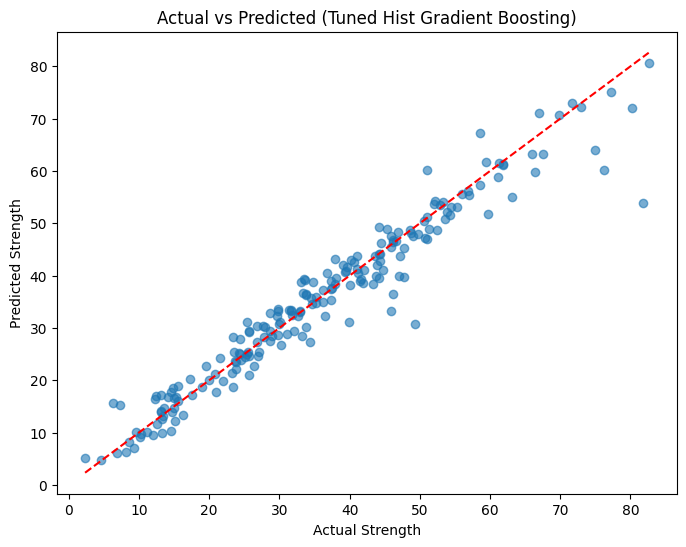

In [36]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    hgb_pred,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Strength")
plt.ylabel("Predicted Strength")
plt.title("Actual vs Predicted (Tuned Hist Gradient Boosting)")
plt.show()

In [54]:
#Deep Learning Model

ann_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(32, activation='relu'),

    Dense(1)
])

c:\Users\DELL\anaconda3\envs\ai_env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [55]:
ann_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [58]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = ann_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 46.4167 - mae: 5.1311 - val_loss: 38.2831 - val_mae: 4.8309
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 41.5331 - mae: 5.0653 - val_loss: 37.8117 - val_mae: 4.8368
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 46.6423 - mae: 5.1947 - val_loss: 37.5733 - val_mae: 4.8397
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 44.2429 - mae: 5.0519 - val_loss: 35.5470 - val_mae: 4.6725
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 47.4528 - mae: 5.2569 - val_loss: 40.3416 - val_mae: 5.0520
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 46.5651 - mae: 5.1631 - val_loss: 36.1905 - val_mae: 4.7195
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 40.9151 - mae: 4.9325 - val_loss: 39.2898 - val_mae: 4.9402
Epoch 8/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 46.4771 - mae: 5.1256 - val_loss: 35.2860 - val_mae: 4.6700
Epoch 9/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/s

In [59]:
ann_pred = ann_model.predict(X_test_scaled).flatten()

ann_r2 = r2_score(y_test, ann_pred)
ann_mae = mean_absolute_error(y_test, ann_pred)
ann_rmse = np.sqrt(mean_squared_error(y_test, ann_pred))

print("ANN Regression Results")
print("-" * 40)
print(f"R² Score : {ann_r2:.4f}")
print(f"MAE      : {ann_mae:.4f}")
print(f"RMSE     : {ann_rmse:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
ANN Regression Results
----------------------------------------
R² Score : 0.8723
MAE      : 4.2183
RMSE     : 6.1729


In [51]:
print("Epochs run:", len(history.history['loss']))

Epochs run: 100


In [60]:
import joblib

# Save ANN model
ann_model.save("ann_concrete_strength_model.keras")

# Save StandardScaler
joblib.dump(scaler, "concrete_scaler.pkl")

['concrete_scaler.pkl']